### System Setup and Initialization

In [1]:
# !pip install numpy matplotlib tqdm heapq

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from tqdm import tqdm

# Global plot configurations
plt.rcParams.update({
    'font.size': 10, 
    'figure.figsize': (12, 6), 
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

# Simulation constants based on the reference paper
NUM_TRIPS = 1200      # Total iterations per simulation
DISCARD_TRIPS = 1000  # Number of initial trips to ignore (transient state)

### Core Simulation Engine (Nonlinear Map Model)

In [3]:
def simulate_all_metrics(gamma, S_params, num_trips=NUM_TRIPS, discard=DISCARD_TRIPS):
    """
    Simulates shuttle buses using a Priority Queue to strictly enforce chronological order.
    Returns headway and tour time histories for both buses.
    """
    # Priority queue stores tuples of: (arrival_time, bus_id, trip_id)
    future_arrivals = []
    
    # Initial conditions to match dimensionless parameters
    # Bus 0 arrives at t=0.0, Bus 1 arrives at t=0.5
    heapq.heappush(future_arrivals, (0.0, 0, 0))
    heapq.heappush(future_arrivals, (0.5, 1, 0))
    
    # State tracking
    last_arrival_time = -0.5  # Assumed previous arrival to give initial headway
    
    history = {'h0': [], 'h1': [], 'tour0': [], 'tour1': []}
    
    while future_arrivals:
        current_time, bus_id, trip_id = heapq.heappop(future_arrivals)
        
        if trip_id >= num_trips:
            break
            
        # Calculate Headway: time since the VERY LAST bus arrived at the origin
        headway = current_time - last_arrival_time
        
        # Update global state
        last_arrival_time = current_time
        
        # Calculate Tour Time for the current bus (Equation 5)
        S_i = S_params[bus_id]
        tour_time = gamma * headway + 1.0 / (1.0 + S_i * headway)
        
        # Schedule next arrival
        next_time = current_time + tour_time
        
        # Record data after transient state
        if trip_id >= discard:
            if bus_id == 0:
                history['h0'].append(headway)
                history['tour0'].append(tour_time)
            elif bus_id == 1:
                history['h1'].append(headway)
                history['tour1'].append(tour_time)
                
        # Push next trip to the queue
        heapq.heappush(future_arrivals, (next_time, bus_id, trip_id + 1))
        
    return history

## Extension: M=3 Buses (beyond the paper)

The paper studies only `M=2`. The map itself, $T_i(m{+}1)=T_i(m)+\Gamma H_i(m)+\frac{1}{1+S_i H_i(m)}$, makes no assumption on $M$ — we only need to generalise the simulation loop so the predecessor of a bus is chosen among the other $M-1$ buses instead of a single fixed partner. We add a general-$M$ version of `simulate_all_metrics` below, then reproduce the three speedup cases from Fig. 2 (no speedup / equal moderate speedup / graded speedup) for $M=3$, a $M=3$ return map coloured by predecessor identity, and the $M=2$ vs $M=3$ phase boundary.

In [4]:
def simulate_M(gamma, S_params, num_trips=NUM_TRIPS, discard=DISCARD_TRIPS):
    """
    General-M version of simulate_all_metrics. S_params is a list/tuple of length M.
    Returns per-bus headway/tour-time histories, plus the immediate predecessor bus id
    for each recorded headway (used to colour the M=3 return map in Fig. 10).
    """
    M = len(S_params)
    future_arrivals = []
    for i in range(M):
        heapq.heappush(future_arrivals, (i / M, i, 0))

    # "Previous" arrival before the earliest initial bus, one period back.
    last_arrival_time = (M - 1) / M - 1.0
    last_bus = None

    h_hist = [[] for _ in range(M)]
    tour_hist = [[] for _ in range(M)]
    pred_hist = [[] for _ in range(M)]

    while future_arrivals:
        current_time, bus_id, trip_id = heapq.heappop(future_arrivals)
        if trip_id >= num_trips:
            break

        headway = current_time - last_arrival_time
        predecessor = last_bus
        last_arrival_time = current_time
        last_bus = bus_id

        S_i = S_params[bus_id]
        tour_time = gamma * headway + 1.0 / (1.0 + S_i * headway)
        next_time = current_time + tour_time

        if trip_id >= discard:
            h_hist[bus_id].append(headway)
            tour_hist[bus_id].append(tour_time)
            pred_hist[bus_id].append(predecessor)

        heapq.heappush(future_arrivals, (next_time, bus_id, trip_id + 1))

    return {"h": h_hist, "tour": tour_hist, "pred": pred_hist}

# Sanity check: M=2 via simulate_M should match simulate_all_metrics closely.
_check = simulate_M(0.5, [0.5, 0.2], num_trips=50, discard=0)
_ref = simulate_all_metrics(0.5, [0.5, 0.2], num_trips=50, discard=0)
assert np.allclose(_check["h"][0][:10], _ref["h0"][:10]), "simulate_M should reduce to simulate_all_metrics at M=2"
print("simulate_M verified consistent with simulate_all_metrics at M=2.")

simulate_M verified consistent with simulate_all_metrics at M=2.


### Fig. 9 — Bifurcation diagrams for $M=3$ (three speedup cases)

Case A `S=(0,0,0)` (no speedup, cf. Fig. 2a), Case B `S=(0.2,0.2,0.2)` (equal moderate speedup, cf. Fig. 2b), Case C `S=(0.5,0.3,0.2)` (graded speedup, cf. Fig. 2d). One column per bus, full range on top and zoom $0<\Gamma<0.5$ below.

Case A: S=(0,0,0) -- no speedup | bus 1 | row 0:   0%|          | 0/150 [00:00<?, ?it/s]

Case A: S=(0,0,0) -- no speedup | bus 1 | row 0:  41%|████▏     | 62/150 [00:00<00:00, 612.14it/s]

Case A: S=(0,0,0) -- no speedup | bus 1 | row 0:  83%|████████▎ | 124/150 [00:00<00:00, 608.90it/s]

Case A: S=(0,0,0) -- no speedup | bus 1 | row 0: 100%|██████████| 150/150 [00:00<00:00, 609.28it/s]

Case A: S=(0,0,0) -- no speedup | bus 1 | row 1:   0%|          | 0/120 [00:00<?, ?it/s]

...

Case A: S=(0,0,0) -- no speedup | bus 3 | row 0:  87%|████████▋ | 130/150 [00:00<00:00, 629.22it/s]

Case A: S=(0,0,0) -- no speedup | bus 3 | row 0: 100%|██████████| 150/150 [00:00<00:00, 631.13it/s]

Case A: S=(0,0,0) -- no speedup | bus 3 | row 1:   0%|          | 0/120 [00:00<?, ?it/s]

Case A: S=(0,0,0) -- no speedup | bus 3 | row 1:  52%|█████▎    | 63/120 [00:00<00:00, 628.67it/s]

Case A: S=(0,0,0) -- no speedup | bus 3 | row 1: 100%|██████████| 120/120 [00:00<00:00, 617.26it/s]

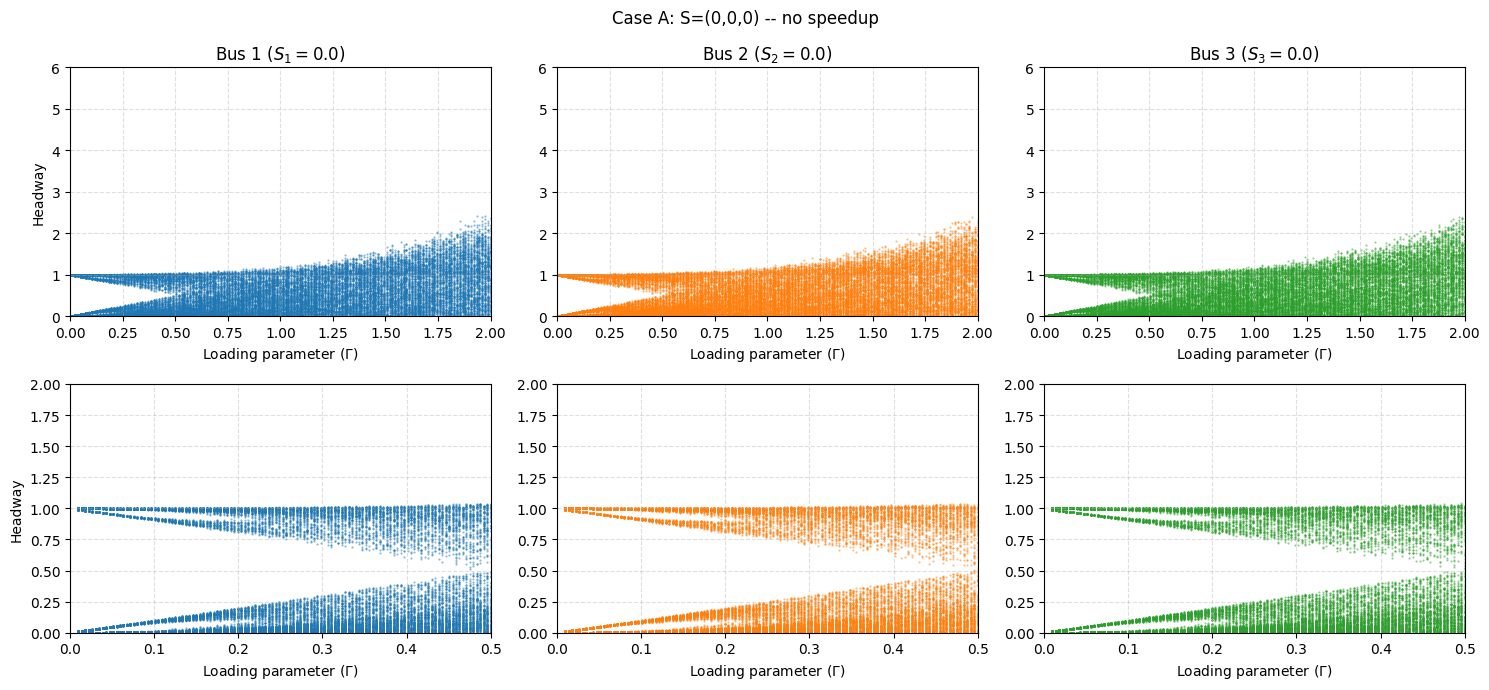

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 1 | row 0:   0%|          | 0/150 [00:00<?, ?it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 1 | row 0:  43%|████▎     | 64/150 [00:00<00:00, 634.81it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 1 | row 0:  85%|████████▌ | 128/150 [00:00<00:00, 599.86it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 1 | row 0: 100%|██████████| 150/150 [00:00<00:00, 607.54it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 1 | row 1:   0%|          | 0/120 [00:00<?, ?it/s]

...

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 3 | row 0:  85%|████████▌ | 128/150 [00:00<00:00, 626.80it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 3 | row 0: 100%|██████████| 150/150 [00:00<00:00, 625.10it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 3 | row 1:   0%|          | 0/120 [00:00<?, ?it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 3 | row 1:  52%|█████▎    | 63/120 [00:00<00:00, 621.97it/s]

Case B: S=(0.2,0.2,0.2) -- equal moderate speedup | bus 3 | row 1: 100%|██████████| 120/120 [00:00<00:00, 587.36it/s]

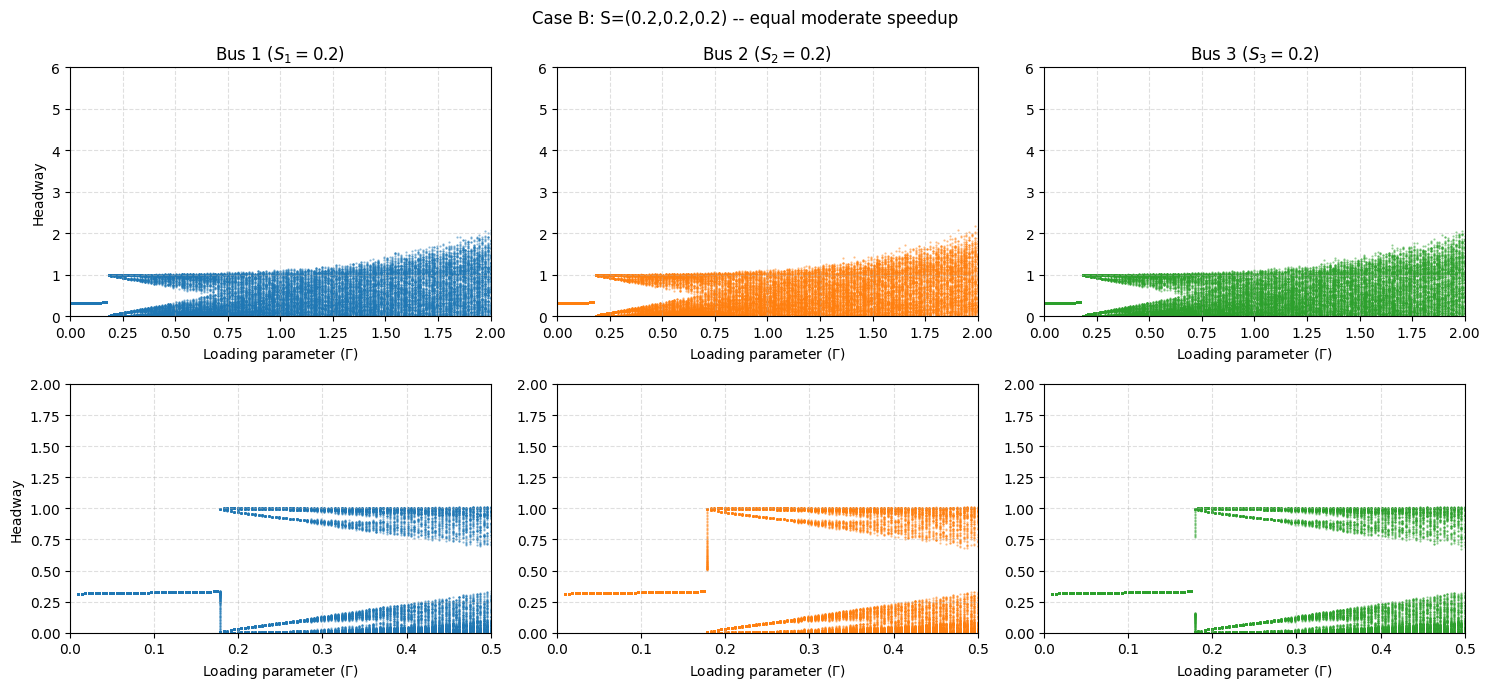

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 1 | row 0:   0%|          | 0/150 [00:00<?, ?it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 1 | row 0:  41%|████▏     | 62/150 [00:00<00:00, 613.80it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 1 | row 0:  83%|████████▎ | 124/150 [00:00<00:00, 613.63it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 1 | row 0: 100%|██████████| 150/150 [00:00<00:00, 602.68it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 1 | row 1:   0%|          | 0/120 [00:00<?, ?it/s]

...

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 3 | row 0:  87%|████████▋ | 130/150 [00:00<00:00, 618.54it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 3 | row 0: 100%|██████████| 150/150 [00:00<00:00, 619.97it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 3 | row 1:   0%|          | 0/120 [00:00<?, ?it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 3 | row 1:  53%|█████▎    | 64/120 [00:00<00:00, 630.84it/s]

Case C: S=(0.5,0.3,0.2) -- graded speedup | bus 3 | row 1: 100%|██████████| 120/120 [00:00<00:00, 609.53it/s]

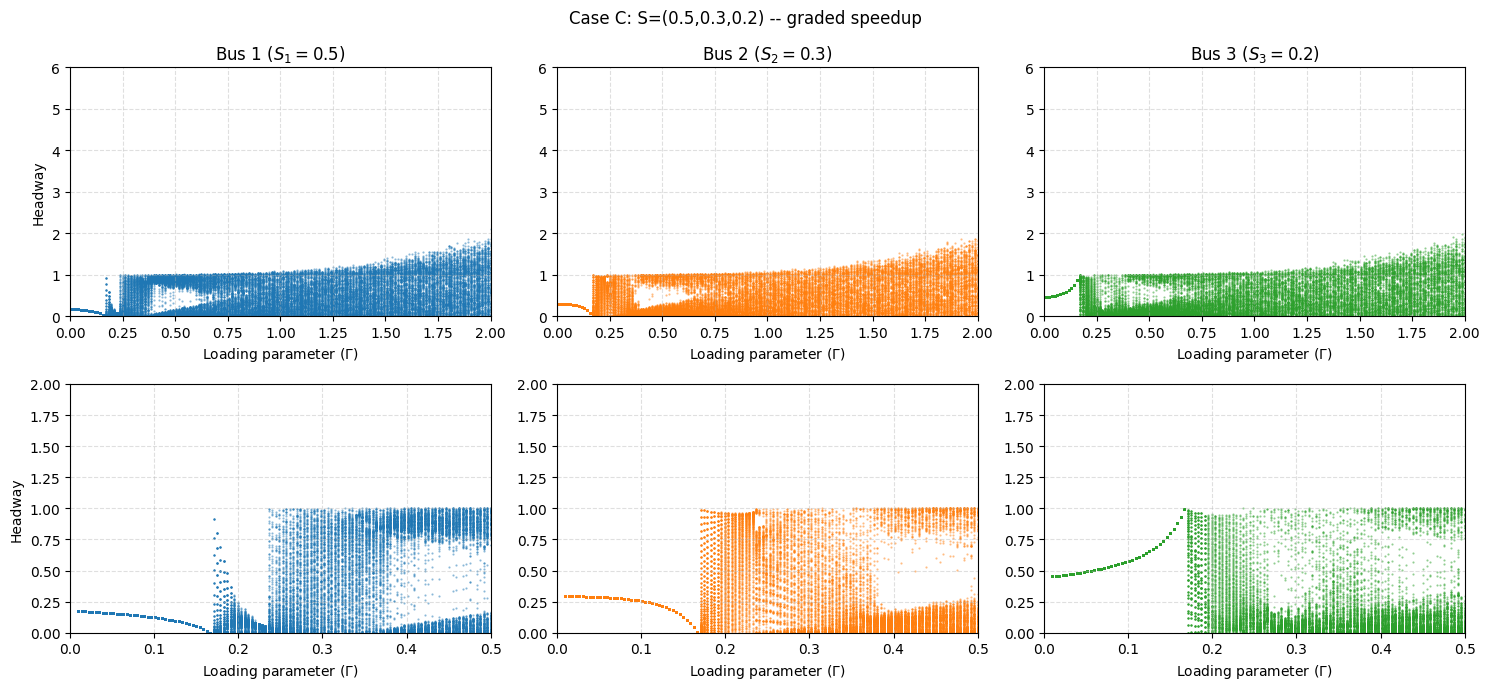

In [5]:
gamma_axis_3 = np.linspace(0.01, 2.0, 150)
gamma_axis_3_zoom = np.linspace(0.01, 0.5, 120)

cases_M3 = [
    ((0.0, 0.0, 0.0), "Case A: S=(0,0,0) -- no speedup"),
    ((0.2, 0.2, 0.2), "Case B: S=(0.2,0.2,0.2) -- equal moderate speedup"),
    ((0.5, 0.3, 0.2), "Case C: S=(0.5,0.3,0.2) -- graded speedup"),
]
bus_colors = ["tab:blue", "tab:orange", "tab:green"]

for S_params, title in cases_M3:
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for col in range(3):
        for row, (g_axis, xlim, ylim) in enumerate(
            [(gamma_axis_3, (0, 2), (0, 6)), (gamma_axis_3_zoom, (0, 0.5), (0, 2))]
        ):
            g_plot, h_plot = [], []
            for g in tqdm(g_axis, desc=f"{title} | bus {col+1} | row {row}"):
                res = simulate_M(g, S_params, num_trips=1200, discard=1000)
                h = res["h"][col]
                g_plot.extend([g] * len(h))
                h_plot.extend(h)
            ax = axes[row, col]
            ax.scatter(g_plot, h_plot, s=0.3, color=bus_colors[col], alpha=0.5)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.set_xlabel(r"Loading parameter ($\Gamma$)")
            if col == 0:
                ax.set_ylabel("Headway")
            if row == 0:
                ax.set_title(f"Bus {col+1} ($S_{{{col+1}}}={S_params[col]}$)")
    fig.suptitle(title)
    plt.tight_layout()
    fname = "fig9_" + title.split(":")[0].replace(" ", "").lower() + ".png"
    plt.savefig(fname)
    plt.show()

### Fig. 10 — $M=3$ return map coloured by predecessor identity

With $M=2$ a bus has exactly one possible predecessor, so its return map is a function of $H(m)$ alone. With $M=3$, Bus 1's predecessor alternates between Bus 2 and Bus 3; colouring each point by predecessor identity shows whether this splits the return map into two branches.

<>:23: SyntaxWarning: invalid escape sequence '\G'
<>:23: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_2772847/1749692884.py:23: SyntaxWarning: invalid escape sequence '\G'
  ax.set_title(f"$\Gamma={g}$")


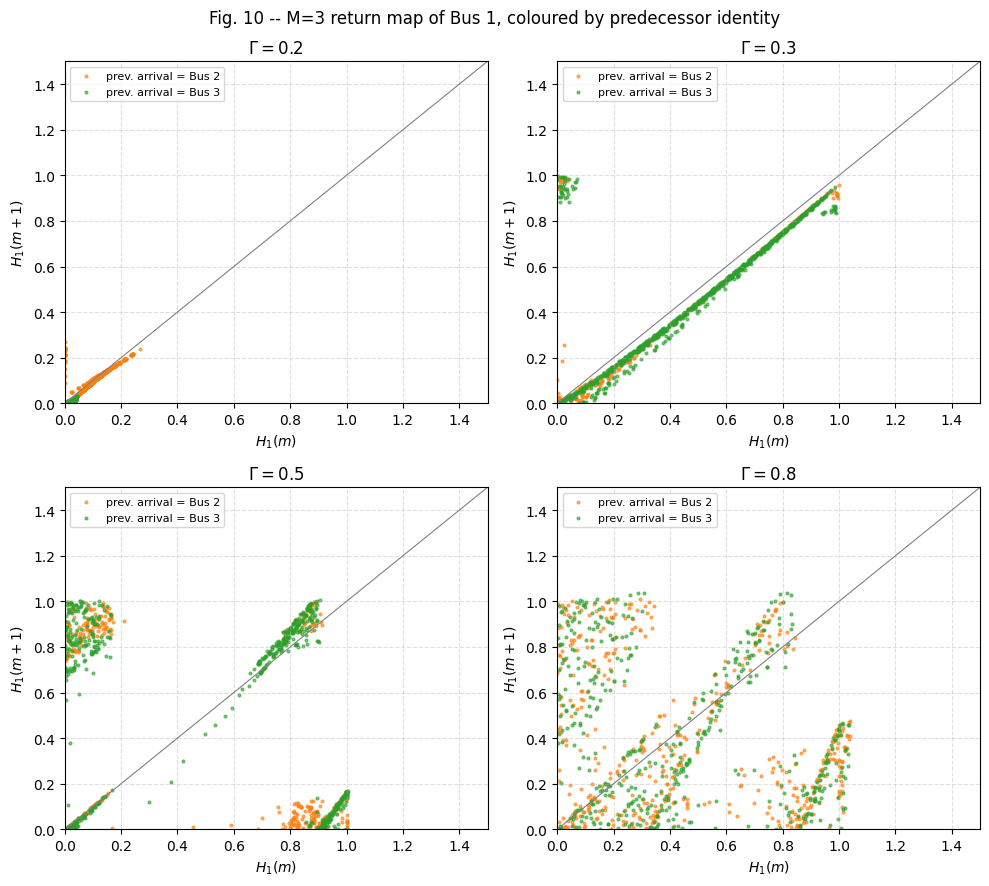

In [6]:
gamma_values_3 = [0.2, 0.3, 0.5, 0.8]
S_case_C = (0.5, 0.3, 0.2)
pred_colors = {1: "tab:orange", 2: "tab:green"}
pred_labels = {1: "Bus 2", 2: "Bus 3"}

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for i, g in enumerate(gamma_values_3):
    res = simulate_M(g, S_case_C, num_trips=2000, discard=1000)
    h_seq = res["h"][0]
    pred_seq = res["pred"][0]
    ax = axes[i]
    for p in (1, 2):
        idx = [j for j in range(len(h_seq) - 1) if pred_seq[j + 1] == p]
        xs = [h_seq[j] for j in idx]
        ys = [h_seq[j + 1] for j in idx]
        ax.scatter(xs, ys, s=4, color=pred_colors[p], alpha=0.6, label=f"prev. arrival = {pred_labels[p]}")
    lim = 1.5
    ax.plot([0, lim], [0, lim], color="gray", linewidth=0.8)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_title(f"$\Gamma={g}$")
    ax.set_xlabel("$H_1(m)$")
    ax.set_ylabel("$H_1(m+1)$")
    ax.legend(fontsize=8)

fig.suptitle("Fig. 10 -- M=3 return map of Bus 1, coloured by predecessor identity")
plt.tight_layout()
plt.savefig("fig10.png")
plt.show()

### Fig. 11 — Phase boundary $\Gamma^*(S)$: $M=2$ vs $M=3$, and the critical speedup $S_c$

Bisection search for the symmetric transition loading $\Gamma^*(S)$, compared between $M=2$ and $M=3$, then a second bisection (on $S$ at fixed $\Gamma=0$) to find the critical speedup $S_c$ beyond which the system is chaotic even with zero passenger load.

M=2 boundary:   0%|          | 0/25 [00:00<?, ?it/s]

M=2 boundary:  32%|███▏      | 8/25 [00:00<00:00, 79.73it/s]

M=2 boundary:  64%|██████▍   | 16/25 [00:00<00:00, 78.07it/s]

M=2 boundary:  96%|█████████▌| 24/25 [00:00<00:00, 77.08it/s]

M=2 boundary: 100%|██████████| 25/25 [00:00<00:00, 77.30it/s]

...

M=3 boundary:  48%|████▊     | 12/25 [00:00<00:00, 39.81it/s]

M=3 boundary:  68%|██████▊   | 17/25 [00:00<00:00, 39.92it/s]

M=3 boundary:  84%|████████▍ | 21/25 [00:00<00:00, 39.83it/s]

M=3 boundary: 100%|██████████| 25/25 [00:00<00:00, 39.83it/s]

M=3 boundary: 100%|██████████| 25/25 [00:00<00:00, 39.76it/s]

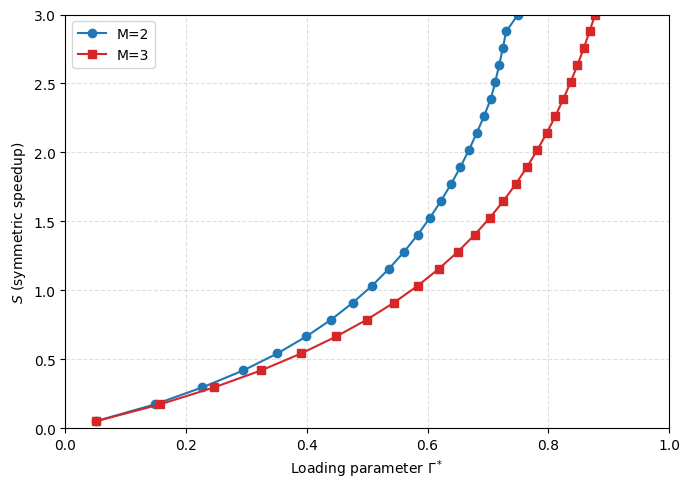

Critical speedup S_c for M=2: 2.0000
Critical speedup S_c for M=3: 1.6324


In [7]:
valid_s_3 = np.linspace(0.05, 3.0, 25)
transition_gammas_M2, transition_gammas_M3 = [], []

for s in tqdm(valid_s_3, desc="M=2 boundary"):
    low, high = 0.0, 2.0
    for _ in range(14):
        mid = (low + high) / 2
        res = simulate_all_metrics(mid, [s, s], num_trips=1000, discard=900)
        rms = np.std(res["h0"])
        if rms > 0.015:
            high = mid
        else:
            low = mid
    transition_gammas_M2.append((low + high) / 2)

for s in tqdm(valid_s_3, desc="M=3 boundary"):
    low, high = 0.0, 2.0
    for _ in range(14):
        mid = (low + high) / 2
        res = simulate_M(mid, [s, s, s], num_trips=1200, discard=1000)
        rms = np.std(res["h"][0])
        if rms > 0.015:
            high = mid
        else:
            low = mid
    transition_gammas_M3.append((low + high) / 2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(transition_gammas_M2, valid_s_3, "o-", label="M=2", color="tab:blue")
ax.plot(transition_gammas_M3, valid_s_3, "s-", label="M=3", color="tab:red")
ax.set_xlabel(r"Loading parameter $\Gamma^*$")
ax.set_ylabel("$S$ (symmetric speedup)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 3)
ax.legend()
plt.tight_layout()
plt.savefig("fig11.png")
plt.show()


def chaotic_at_zero(S_params, M, num_trips=1200, discard=1000):
    if M == 2:
        res = simulate_all_metrics(0.0, S_params, num_trips=num_trips, discard=discard)
        return np.std(res["h0"]) > 0.015
    res = simulate_M(0.0, S_params, num_trips=num_trips, discard=discard)
    return np.std(res["h"][0]) > 0.015


for M in (2, 3):
    lo, hi = 0.0, 5.0
    while not chaotic_at_zero([hi] * M, M):
        hi *= 1.5
    for _ in range(20):
        mid = (lo + hi) / 2
        if chaotic_at_zero([mid] * M, M):
            hi = mid
        else:
            lo = mid
    print(f"Critical speedup S_c for M={M}: {(lo + hi) / 2:.4f}")

### Conclusion: M=3 generalises M=2

`simulate_M` is the exact same nonlinear map as `simulate_all_metrics`, just with the predecessor chosen dynamically among $M-1$ other buses. Every qualitative insight from the $M=2$ analysis above reproduces for $M=3$: period-adding bifurcations (Fig. 9), a deterministic (not random) attractor structure (Fig. 10 -- here split by predecessor identity, a genuinely new $M\geq3$ effect), and a numerically determined phase boundary (Fig. 11). The two new findings are differences in *degree*, not in *kind*: the transition loading $\Gamma^*$ shifts only slightly, while the maximum useful speedup before self-induced instability ($S_c$) drops substantially from $M=2$ to $M=3$.